# 05. Can the biases be exploited?

A bias only matters to a trader if it survives execution costs. This notebook tests two strategies fixed in advance, with realistic execution:

- **A. Selling lottery tickets at the price floor.** Markets quoted at 1 cent never won in our sample. Can a trader collect that cent?
- **B. Backing sports favorites.** Sports showed the only robust favorite-longshot bias. Does buying favorites one day before the game make money after the spread and fees?

**Fees.** Kalshi's taker fee is round_up(M × 0.07 × C × P × (1 − P)) to the next cent per order, where C is the number of contracts, P the price and M the series multiplier (stored in `series_universe.csv`). Maker fees, on the series that charge them, use 0.0175 instead of 0.07. We assume orders of 100 contracts, so the rounding is spread over 100 contracts.

**Provisional results**: validation sample of 10 events per series.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmcal.calibration import cluster_bootstrap
from pmcal.report import fmt

N_BOOT = int(os.environ.get("N_BOOT", 2000))
MIN_VOLUME = 10_000
ORDER_SIZE = 100
TAKER_RATE, MAKER_RATE = 0.07, 0.0175

series = pd.read_csv(ROOT / "data" / "series_universe.csv")[["ticker", "fee_type", "fee_multiplier"]]
obs = (pd.read_parquet(ROOT / "data" / "observations.parquet")
         .merge(series, left_on="series_ticker", right_on="ticker", suffixes=("", "_series"))
         .drop(columns="ticker_series"))
obs = obs[obs["volume_before"] >= MIN_VOLUME].copy()
print(f"Bootstrap draws: {N_BOOT:,}. {len(obs):,} observations")

def fee_per_contract(price, multiplier, rate):
    """Fee of one 100-contract order, rounded up to the cent, divided by 100."""
    raw = multiplier * rate * ORDER_SIZE * price * (1 - price)
    return np.ceil(np.round(raw * 100, 9)) / 100 / ORDER_SIZE

def pnl_ci(d, label):
    """Mean P&L per contract and return on capital, with cluster-bootstrap CIs."""
    f = lambda x: {"pnl_cents": 100 * x["pnl"].mean(), "roi_pct": 100 * x["pnl"].sum() / x["cost"].sum()}
    ci = cluster_bootstrap(d, f, "event_ticker", n_boot=N_BOOT)
    return {"strategy": label, "trades": len(d), "events": d["event_ticker"].nunique(),
            "P&L per contract (cents)": fmt(*ci.loc["pnl_cents"], d=2),
            "return on capital (%)": fmt(*ci.loc["roi_pct"], d=1)}

Bootstrap draws: 2,000. 12,970 observations


## A. Selling lottery tickets at the price floor

Selling Yes at 1 cent means buying No at 99 cents. As a **taker**, this needs a buyer of Yes resting in the book at 1 cent or more. The first table checks whether one exists.

In [2]:
floor = obs[obs["price"] <= 0.01]
pd.DataFrame({
    "observations at the floor": floor.groupby("horizon").size(),
    "with a Yes bid >= 0.01": floor[floor["yes_bid"] >= 0.01].groupby("horizon").size(),
    "Yes outcomes": floor.groupby("horizon")["outcome"].sum(),
}).fillna(0).astype(int)

,observations at the floor,with a Yes bid >= 0.01,Yes outcomes
horizon,,,
1d,770,0,0
1h,2876,1,1
30d,83,0,0
7d,225,0,0


Almost no floor observation has a Yes bid. The 1-cent price is set by buyers **lifting** a resting offer at 1 cent. A taker cannot collect the cent: the only way is to be the one posting that offer, as a **maker**.

The maker version below is an **upper bound**. It assumes every resting offer at 1 cent is filled, while in practice other makers are already queued at that price and fills are not guaranteed.

In [3]:
mk = floor.copy()
mk["cost"] = 0.99                      # buying No at 99 cents
maker_fee = np.where(mk["fee_type"].str.contains("maker"), fee_per_contract(0.01, mk["fee_multiplier"], MAKER_RATE), 0.0)
mk["pnl"] = (1 - mk["outcome"]) - 0.99 - maker_fee
res_a = pd.DataFrame([pnl_ci(mk[mk["horizon"] == h], f"maker at the floor, T-{h}") for h in ["1h", "1d", "7d", "30d"] if (mk["horizon"] == h).any()])
res_a

,strategy,trades,events,P&L per contract (cents),return on capital (%)
0,"maker at the floor, T-1h",2876,1098,"0.96 [0.89, 1.00]","1.0 [0.9, 1.0]"
1,"maker at the floor, T-1d",770,276,"0.99 [0.99, 1.00]","1.0 [1.0, 1.0]"
2,"maker at the floor, T-7d",225,101,"0.99 [0.99, 0.99]","1.0 [1.0, 1.0]"
3,"maker at the floor, T-30d",83,40,"0.99 [0.99, 1.00]","1.0 [1.0, 1.0]"


**How much could be deployed?** Zero losses in the sample does not mean zero risk. With n trades and no loss, the rule of three puts the 95% upper bound of the loss probability near 3/n. One loss costs 99 cents, about a hundred winning trades.

In [4]:
n = len(floor)
p_up = 3 / n
print(f"{n:,} floor observations, {int(floor['outcome'].sum())} losses for the seller")
print(f"95% upper bound on the loss probability: {p_up:.2%}")
print(f"Worst-case expected P&L per contract at that bound: {100 * (0.01 - p_up):.2f} cents before fees")

3,954 floor observations, 1 losses for the seller
95% upper bound on the loss probability: 0.08%
Worst-case expected P&L per contract at that bound: 0.92 cents before fees


## B. Backing sports favorites one day before the game

At T-1d, buy the favorite of every sports market with a price between 0.02 and 0.98. The favorite is bought at the **ask**: the Yes ask when Yes is the favorite, and 1 minus the Yes bid when No is the favorite. A taker fee is paid on entry; there is no fee at settlement.

Three versions separate the sources of cost: at the midpoint with no fee, at the ask with no fee, and at the ask with fees.

In [5]:
sp = obs[(obs["family"] == "sports") & (obs["horizon"] == "1d") & (obs["price"] > 0.02) & (obs["price"] < 0.98)].copy()
sp = sp[(sp["yes_bid"] > 0) & (sp["yes_ask"] < 1)]   # two-sided book needed to trade
yes_fav = sp["price"] >= 0.5
sp["fav_mid"] = np.where(yes_fav, sp["price"], 1 - sp["price"])
sp["fav_ask"] = np.where(yes_fav, sp["yes_ask"], 1 - sp["yes_bid"])
sp["fav_won"] = np.where(yes_fav, sp["outcome"], 1 - sp["outcome"])
sp["fee"] = fee_per_contract(sp["fav_ask"], sp["fee_multiplier"], TAKER_RATE)

versions = {
    "midpoint, no fee": (sp["fav_mid"], 0.0),
    "ask, no fee": (sp["fav_ask"], 0.0),
    "ask, taker fee": (sp["fav_ask"], sp["fee"]),
}
rows = []
for name, (px, fee) in versions.items():
    d = sp.assign(cost=px + fee, pnl=sp["fav_won"] - px - fee)
    rows.append(pnl_ci(d, name))
res_b = pd.DataFrame(rows)
print(f"Median spread {100 * sp['spread'].median():.1f} cents, median fee {100 * sp['fee'].median():.2f} cents per contract")
res_b

Median spread 1.0 cents, median fee 1.50 cents per contract


,strategy,trades,events,P&L per contract (cents),return on capital (%)
0,"midpoint, no fee",711,358,"-0.42 [-4.38, 3.47]","-0.6 [-6.2, 5.0]"
1,"ask, no fee",711,358,"-1.10 [-5.03, 2.83]","-1.6 [-7.1, 4.0]"
2,"ask, taker fee",711,358,"-2.38 [-6.30, 1.54]","-3.3 [-8.8, 2.2]"


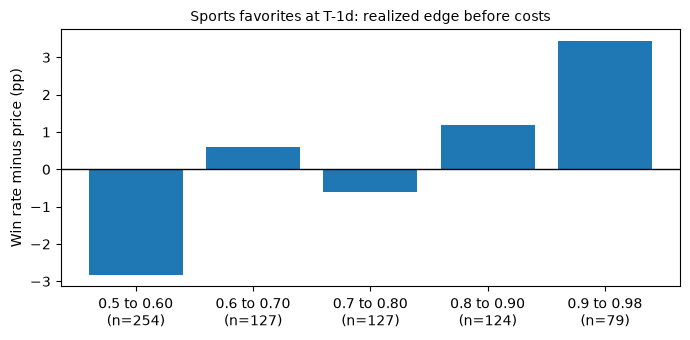

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
b = pd.cut(sp["fav_mid"], [0.5, 0.6, 0.7, 0.8, 0.9, 0.98], include_lowest=True)
g = sp.groupby(b, observed=True).agg(n=("fav_won", "size"), won=("fav_won", "mean"), mid=("fav_mid", "mean"))
ax.bar(range(len(g)), 100 * (g["won"] - g["mid"]))
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(g)), [f"{i.left:.1f} to {i.right:.2f}\n(n={n})" for i, n in zip(g.index, g["n"])])
ax.set_ylabel("Win rate minus price (pp)")
ax.set_title("Sports favorites at T-1d: realized edge before costs", fontsize=10)
plt.tight_layout()
fig.savefig(ROOT / "figures" / "sports_favorite_edge.png", dpi=150)
plt.show()

## Export

In [7]:
pd.concat([res_a, res_b]).to_csv(ROOT / "data" / "results_exploitability.csv", index=False)
print("Saved")

Saved
